<a href="https://colab.research.google.com/github/Sharddha-Sharddha/IITMLAssignments/blob/main/WindEnergyEfficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#dataset link: https://drive.google.com/file/d/1M6FvL6A6L10k2ggYx91qrfvQMeT6SAbo/view?usp=drive_link

In [ ]:
#TASK:
#1. Data Exploration
#2. EDA
#3. Model Building
#4. Model Deployment(if possible in the last 30 mins)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data/WindEnergyEfficiency.csv')
df.head()

,timestamp,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,turbine_id,Target
0,2021-02-19 20:18:00,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,Turbine_108,47.582787
1,2021-04-27 04:55:00,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,Turbine_18,46.070328
2,2021-01-25 06:26:00,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,Turbine_105,39.989236
3,2021-10-30 03:47:00,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,Turbine_15,46.056587
4,2021-03-15 00:39:00,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,Turbine_01,54.346095


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909604 entries, 0 to 909603
Data columns (total 16 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   timestamp                               909604 non-null  object 
 1   active_power_calculated_by_converter    909604 non-null  float64
 2   active_power_raw                        909604 non-null  float64
 3   ambient_temperature                     909604 non-null  float64
 4   generator_speed                         909604 non-null  float64
 5   generator_winding_temp_max              909604 non-null  float64
 6   grid_power10min_average                 909604 non-null  float64
 7   nc1_inside_temp                         909604 non-null  float64
 8   nacelle_temp                            909604 non-null  float64
 9   reactice_power_calculated_by_converter  909604 non-null  float64
 10  reactive_power                          9096

In [ ]:
df.memory_usage()

,0
Index,132
timestamp,7276832
active_power_calculated_by_converter,7276832
active_power_raw,7276832
ambient_temperature,7276832
generator_speed,7276832
generator_winding_temp_max,7276832
grid_power10min_average,7276832
nc1_inside_temp,7276832
nacelle_temp,7276832


In [ ]:
df.isnull().sum()


,0
timestamp,0
active_power_calculated_by_converter,0
active_power_raw,0
ambient_temperature,0
generator_speed,0
generator_winding_temp_max,0
grid_power10min_average,0
nc1_inside_temp,0
nacelle_temp,0
reactice_power_calculated_by_converter,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
active_power_calculated_by_converter,909604.0,525.886061,474.619576,0.000000,149.620898,379.989929,781.357475,1999.999858
active_power_raw,909604.0,537.639468,482.394907,0.000008,155.813244,383.985926,800.261108,1999.984456
ambient_temperature,909604.0,25.573921,8.025649,5.616541,17.093680,27.919035,32.171696,48.089017
generator_speed,909604.0,931.130882,193.674384,0.000000,770.538574,884.068502,1123.335856,1267.140625
generator_winding_temp_max,909604.0,60.730112,9.721582,25.636366,54.916767,60.034490,65.737187,129.846405
grid_power10min_average,909604.0,527.579537,472.656976,0.000000,147.181552,391.303187,794.875710,1999.991455
nc1_inside_temp,909604.0,31.755823,3.929794,11.141922,29.913803,31.762946,33.469745,52.790030
nacelle_temp,909604.0,31.686413,3.554426,16.010218,30.267423,31.961610,33.546260,48.406106
reactice_power_calculated_by_converter,909604.0,111.080610,78.219944,-318.393721,81.540850,92.005826,124.879153,523.892695
reactive_power,909604.0,133.692333,91.232152,-5.461607,96.045765,107.633378,154.153730,592.815938


In [ ]:
num_cols = df.select_dtypes(include = 'number').columns
num_cols
number_column = df.select_dtypes(include = 'number')
number_column

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,Target
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,47.582787
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,46.070328
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,39.989236
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,46.056587
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,50.768675
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,44.234821
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,46.942486
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,46.392221


In [ ]:
df[num_cols].skew()

,0
active_power_calculated_by_converter,1.094894
active_power_raw,1.079560
ambient_temperature,-0.405606
generator_speed,-0.432870
generator_winding_temp_max,0.482791
grid_power10min_average,1.008062
nc1_inside_temp,0.040530
nacelle_temp,-0.427542
reactice_power_calculated_by_converter,1.731298
reactive_power,1.638332


In [ ]:
pt = PowerTransformer(method='yeo-johnson', standardize= False)
df['wind_speed_turbulence']= pt.fit_transform(df[['wind_speed_turbulence']])


In [ ]:
df[num_cols].skew()

,0
active_power_calculated_by_converter,1.094894
active_power_raw,1.079560
ambient_temperature,-0.405606
generator_speed,-0.432870
generator_winding_temp_max,0.482791
grid_power10min_average,1.008062
nc1_inside_temp,0.040530
nacelle_temp,-0.427542
reactice_power_calculated_by_converter,1.731298
reactive_power,1.638332


In [ ]:
df[num_cols]

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,Target
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.304293,47.582787
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.279945,46.070328
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.326438,39.989236
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.359154,46.056587
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.231749,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,0.405833,50.768675
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.319286,44.234821
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.394109,46.942486
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.183297,46.392221


In [ ]:
for col in number_column:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  IQR = q1 * q3

  upper_limit = q3 + (1.5* IQR)
  lower_limit =  q1 - (1.5* IQR)

  outlier = df[(df[col]>upper_limit)|(df[col]<lower_limit)]

  print(f"Column: {col} | Number of outliers: {len(outlier)}")



Column: active_power_calculated_by_converter | Number of outliers: 0
Column: active_power_raw | Number of outliers: 0
Column: ambient_temperature | Number of outliers: 0
Column: generator_speed | Number of outliers: 0
Column: generator_winding_temp_max | Number of outliers: 0
Column: grid_power10min_average | Number of outliers: 0
Column: nc1_inside_temp | Number of outliers: 0
Column: nacelle_temp | Number of outliers: 0
Column: reactice_power_calculated_by_converter | Number of outliers: 0
Column: reactive_power | Number of outliers: 0
Column: wind_direction_raw | Number of outliers: 0
Column: wind_speed_raw | Number of outliers: 0
Column: wind_speed_turbulence | Number of outliers: 1069
Column: Target | Number of outliers: 0


/tmp/ipykernel_2968/1509934126.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['wind_speed_turbulence'])


<Axes: xlabel='wind_speed_turbulence', ylabel='Density'>

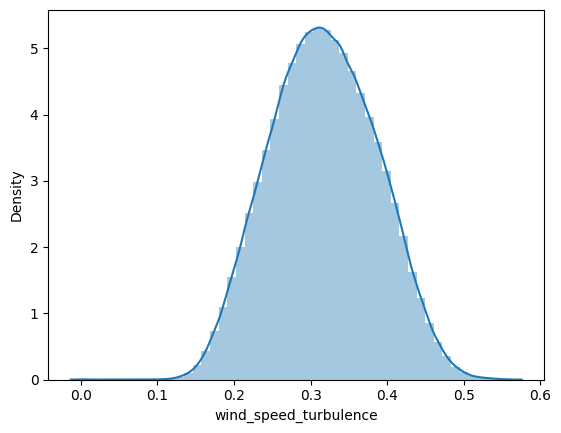

In [ ]:
sns.distplot(df['wind_speed_turbulence'])

In [ ]:
for col in number_column:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  IQR = q1 * q3

  upper_limit = q3 + (1.5* IQR)
  lower_limit =  q1 - (1.5* IQR)

  df[col]= np.clip(df[col], lower_limit, upper_limit)


In [ ]:
for col in number_column:
  q1 = df[col].quantile(0.05)
  q3 = df[col].quantile(0.95)

  IQR = q1 * q3

  upper_limit = q3 + (1.5* IQR)
  lower_limit =  q1 - (1.5* IQR)

  outlier = df[(df[col]>upper_limit)|(df[col]<lower_limit)]

  print(f"Column: {col} | Number of outliers: {len(outlier)}")

Column: active_power_calculated_by_converter | Number of outliers: 0
Column: active_power_raw | Number of outliers: 0
Column: ambient_temperature | Number of outliers: 0
Column: generator_speed | Number of outliers: 0
Column: generator_winding_temp_max | Number of outliers: 0
Column: grid_power10min_average | Number of outliers: 0
Column: nc1_inside_temp | Number of outliers: 0
Column: nacelle_temp | Number of outliers: 0
Column: reactice_power_calculated_by_converter | Number of outliers: 0
Column: reactive_power | Number of outliers: 0
Column: wind_direction_raw | Number of outliers: 0
Column: wind_speed_raw | Number of outliers: 0
Column: wind_speed_turbulence | Number of outliers: 0
Column: Target | Number of outliers: 0


/tmp/ipykernel_2968/1509934126.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['wind_speed_turbulence'])


<Axes: xlabel='wind_speed_turbulence', ylabel='Density'>

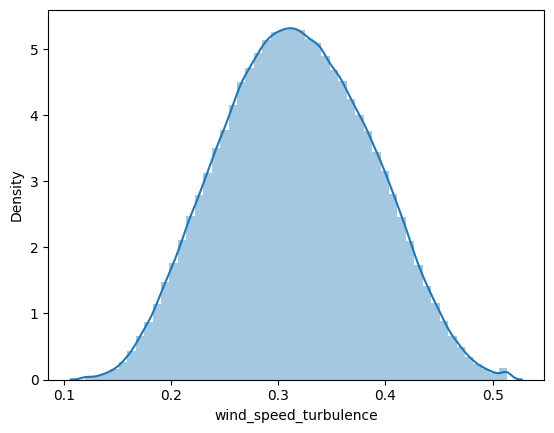

In [ ]:
sns.distplot(df['wind_speed_turbulence'])

In [ ]:
number_column

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence,Target
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082,47.582787
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031,46.070328
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318,39.989236
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719,46.056587
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068,54.346095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960,50.768675
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874,44.234821
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241,46.942486
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335,46.392221


In [ ]:
# 2. Build the VIF DataFrame
vif = pd.DataFrame() # Changed df.DataFrame() to pd.DataFrame()
vif['features'] = number_column.columns

# 3. Calculate VIF (Fixed the 'num_cols' typo in the loop)
vif['multicollinearity'] = [variance_inflation_factor(number_column.values, i) for i in range(len(number_column.columns))]

# 4. Sort to see the worst offenders at the top
print(vif.sort_values('multicollinearity', ascending=False))

                                  features  multicollinearity
9                           reactive_power         429.298008
0     active_power_calculated_by_converter         415.177263
1                         active_power_raw         364.732872
8   reactice_power_calculated_by_converter         329.712619
7                             nacelle_temp         285.551946
13                                  Target         275.388887
4               generator_winding_temp_max         156.569831
6                          nc1_inside_temp         140.040050
3                          generator_speed          97.863791
11                          wind_speed_raw          80.652029
5                  grid_power10min_average          32.120520
2                      ambient_temperature          13.840028
12                   wind_speed_turbulence           7.826775
10                      wind_direction_raw           4.831214


In [ ]:
x = number_column.drop(columns = ['Target'],axis = 1,)
x

,active_power_calculated_by_converter,active_power_raw,ambient_temperature,generator_speed,generator_winding_temp_max,grid_power10min_average,nc1_inside_temp,nacelle_temp,reactice_power_calculated_by_converter,reactive_power,wind_direction_raw,wind_speed_raw,wind_speed_turbulence
0,816.636759,834.917206,31.694380,1159.616602,65.954214,917.897085,31.881972,31.504713,141.457644,165.501518,280.864782,7.057000,0.544082
1,419.107829,421.050873,12.894948,928.747996,59.571319,445.554250,32.423705,32.755770,89.186457,113.835236,299.552460,5.474937,0.469031
2,1303.530558,1337.566142,16.648388,1201.219775,61.270498,1364.716003,11.446849,18.332985,230.622309,281.452253,84.960106,8.092457,0.622318
3,61.494872,53.481008,28.388141,769.806122,40.674348,14.324897,34.253204,32.662889,66.211015,75.017531,87.261119,4.071032,0.760719
4,593.514364,611.659108,31.519527,1046.916768,64.341763,599.020172,32.405586,31.466387,137.163938,160.202421,313.724818,6.357943,0.346068
...,...,...,...,...,...,...,...,...,...,...,...,...,...
909599,929.101908,948.441905,32.736076,1187.303192,83.187140,1343.320577,32.291391,35.152280,152.216446,191.088800,189.901812,7.155343,1.028960
909600,100.730526,88.694599,30.540500,770.245593,56.235497,177.620552,30.434302,29.932141,85.353107,96.621675,93.417590,4.121607,0.595874
909601,1120.915965,1165.016907,30.901129,1170.456860,62.942943,873.414622,30.491818,33.085164,42.820210,74.111173,230.988398,8.551669,0.951241
909602,123.444564,116.066919,32.697933,770.190796,57.245207,95.865704,32.338824,31.525384,86.549094,97.470984,65.408801,4.324064,0.247335


In [ ]:
y = number_column['Target']
y

,Target
0,47.582787
1,46.070328
2,39.989236
3,46.056587
4,54.346095
...,...
909599,50.768675
909600,44.234821
909601,46.942486
909602,46.392221


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.20, random_state= True)

In [ ]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=50, max_depth=15, random_state=42, n_jobs = -1)
xgb = XGBRegressor(n_estimators=100, random_state = 42, n_jobs = -1)

In [ ]:
print("Training Random Forest...")
rf.fit(x_train,y_train)


Training Random Forest...


RandomForestRegressor(max_depth=15, n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
print("Training XGboost...")
xgb.fit(x_train,y_train)

Training XGboost...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# 4. Hyperparameter Tuning for XGBoost using Random Search
param_distribution = {
    'xg_boost__n_estimators': [100,200,300],
    'xg_boost__learning_rate': [0.001,0.01,0.1],
    'xg_boost__max_dept': [3,5,7]
}

xgb_hyperparameter = RandomizedSearchCV(estimator = xgb,
                                        param_distributions = param_distribution,
                                        n_iter=5,          # Tests 5 random combinations to save time
                                        cv = 3,   # 3-fold
                                        verbose=2,
                                        random_state=42
                                        )

In [ ]:
xgb_hyperparameter.fit(x_train,y_train)
best_xgb_model= xgb_hyperparameter.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:11:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "xg_boost__learning_rate", "xg_boost__max_dept", "xg_boost__n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xg_boost__learning_rate=0.001, xg_boost__max_dept=7, xg_boost__n_estimators=300; total time=   4.2s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:11:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "xg_boost__learning_rate", "xg_boost__max_dept", "xg_boost__n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xg_boost__learning_rate=0.001, xg_boost__max_dept=7, xg_boost__n_estimators=300; total time=   6.9s


...

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:12:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "xg_boost__learning_rate", "xg_boost__max_dept", "xg_boost__n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xg_boost__learning_rate=0.001, xg_boost__max_dept=3, xg_boost__n_estimators=100; total time=   4.3s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:13:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "xg_boost__learning_rate", "xg_boost__max_dept", "xg_boost__n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END xg_boost__learning_rate=0.001, xg_boost__max_dept=3, xg_boost__n_estimators=100; total time=   4.4s


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:13:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "xg_boost__learning_rate", "xg_boost__max_dept", "xg_boost__n_estimators" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
y_pred_xgb = best_xgb_model.predict(x_test)

In [ ]:
# 5. Predictions and Evaluation

In [ ]:
r2_rf= r2_score(y_test,y_pred_rf)
print(f' r2 score for randomforest : {r2_rf}')


 r2 score for randomforest : 0.7229648530020104


In [ ]:
r2_xgb= r2_score(y_test,y_pred_xgb)
print(f' r2 score for xgb with randomizedsearchCV : {r2_xgb}')

 r2 score for xgb with randomizedsearchCV : 0.6719294242831821


/tmp/ipykernel_2968/2491102635.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test, label= 'Actual')
/tmp/ipykernel_2968/2491102635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred_rf, label=' Predicted_RF')
/tmp/ipykernel_2968/2491102635.py:3: UserWarning: 

`distplot` is a dep

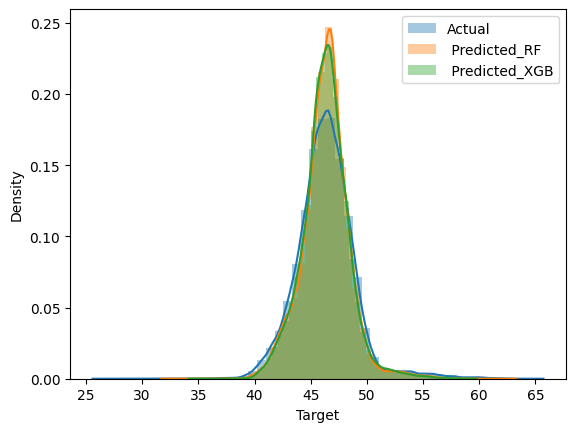

In [ ]:
sns.distplot(y_test, label= 'Actual')
sns.distplot(y_pred_rf, label=' Predicted_RF')
sns.distplot(y_pred_xgb, label=' Predicted_XGB')
plt.legend()
plt.show()